In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

patients = pd.read_csv("patients_clean.csv")
encounters = pd.read_csv("encounters_clean.csv")
procedures = pd.read_csv("procedures_clean.csv")
payers = pd.read_csv("payers_clean.csv")

# Demographic Analysis

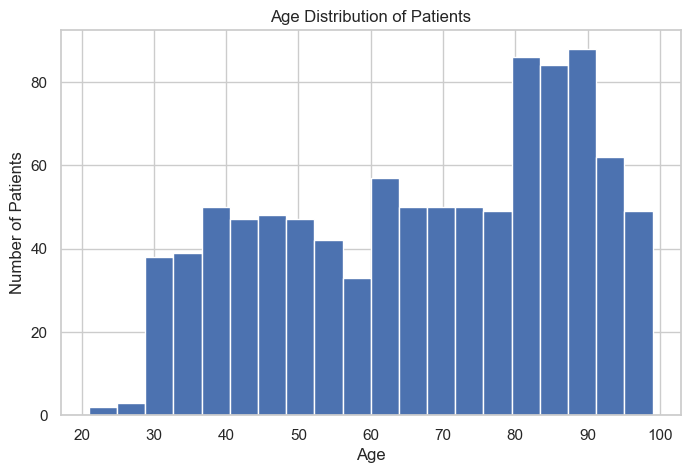

In [3]:
# Age distribution of Patients

plt.figure(figsize=(8,5))
plt.hist(patients["age"].dropna(), bins=20)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

# KEY INSIGHTS
 The patient population is skewed towards older age groups, with a significant concentration between 70–90 years.

This suggests that the dataset represents a predominantly elderly population, indicating higher healthcare utilization among senior patients.

Very few patients are below 30, highlighting limited representation of younger individuals.

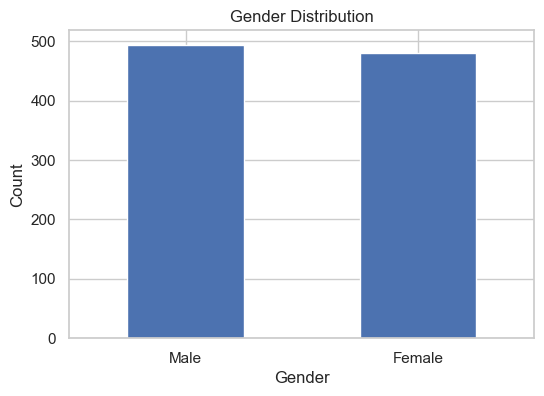

In [4]:
# Gender distribution
patients["gender"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# KEY INSIGHTS
The dataset shows an almost equal distribution of male and female patients.

This indicates no significant gender bias in patient representation.

Any variation in healthcare cost or utilization across gender is likely due to behavioral or medical factors rather than sample imbalance.

# Encounter Analysis

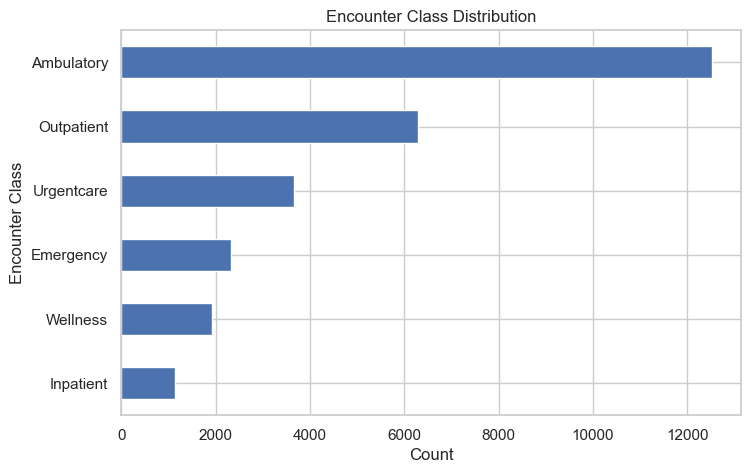

In [5]:
# Encounter Class Distribution
encounters["encounter_class"].value_counts().sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Encounter Class Distribution")
plt.xlabel("Count")
plt.ylabel("Encounter Class")
plt.show()


# KEY INSIGHTS:

The majority of healthcare interactions are ambulatory visits, followed by outpatient consultations, indicating that most treatments do not require hospital admission.

Emergency and urgent care visits are comparatively lower, suggesting fewer acute or critical cases in the dataset.

Inpatient admissions are minimal, highlighting that hospitalization is relatively rare and reserved for serious conditions.

The presence of wellness visits further indicates a portion of preventive healthcare usage among patients.1


In [7]:
#Analyzing by Encounter Type
encounters.groupby("encounter_class")["duration_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
encounter_class,,,,,,,,
Ambulatory,12517.0,0.976377,5.993479,0.25,0.25,0.25,0.920278,659.000000
Emergency,2322.0,1.541755,14.929700,1.00,1.00,1.00,1.000000,589.000000
Inpatient,1133.0,28.438831,31.841045,24.00,24.00,24.00,24.000000,552.000000
Outpatient,6283.0,0.276220,0.129202,0.25,0.25,0.25,0.250000,1.919444
Urgentcare,3665.0,0.250000,0.000000,0.25,0.25,0.25,0.250000,0.250000
Wellness,1931.0,0.250000,0.000000,0.25,0.25,0.25,0.250000,0.250000


In [12]:
encounters["encounter_class"] = encounters["encounter_class"].str.strip().str.lower()

In [13]:
outpatient = encounters[encounters["encounter_class"].isin(["ambulatory", "outpatient"])]
inpatient = encounters[encounters["encounter_class"] == "inpatient"]

In [15]:
print(outpatient.shape)
print(inpatient.shape)

(18800, 21)
(1133, 21)


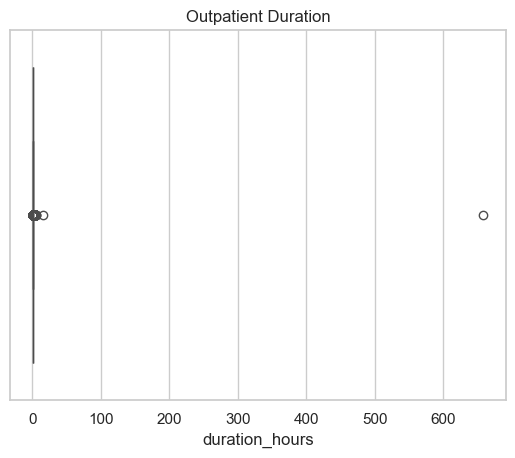

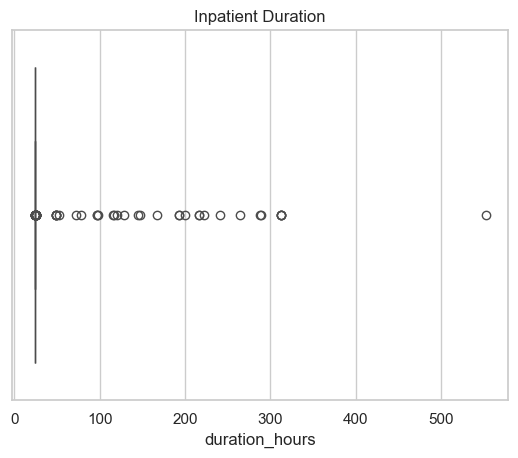

In [16]:
# Outpatient vs Inpatient

sns.boxplot(x=outpatient["duration_hours"])
plt.title("Outpatient Duration")
plt.show()

sns.boxplot(x=inpatient["duration_hours"])
plt.title("Inpatient Duration")
plt.show()

# KEY INSIGHTS:

Outpatient encounters are highly concentrated in very short durations, typically under 1 hour, indicating routine consultations and minor treatments.

Outliers in outpatient duration (e.g., >100 hours) are likely data inconsistencies and should be investigated or capped before further analysis.

In contrast, inpatient encounters show significantly longer durations, often extending to several days, reflecting hospital admissions and intensive care.

However, both categories still exhibit extreme outliers, suggesting either prolonged treatments or potential inconsistencies in duration recording.



# Procedure Analysis

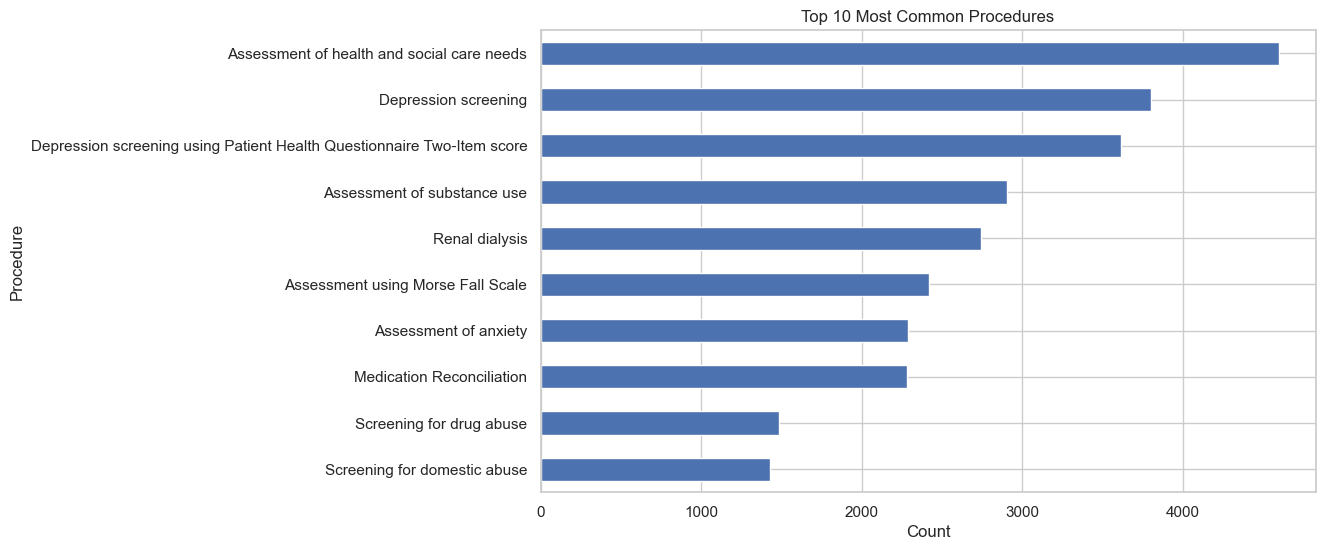

In [21]:
# top 10 procedures

top_procedures = procedures["procedure_description"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_procedures.sort_values().plot(kind="barh")
plt.title("Top 10 Most Common Procedures")
plt.xlabel("Count")
plt.ylabel("Procedure")
plt.show()

# KEY INSIGHTS
The most frequently performed procedures are preventive and assessment-based, such as health evaluations, depression screening, and substance use assessment.

Mental health–related procedures (depression, anxiety, substance abuse) appear prominently, indicating a strong focus on behavioral health monitoring.

High frequency of screening and assessment procedures suggests that the healthcare system emphasizes early detection and preventive care rather than reactive treatment.

The presence of procedures like renal dialysis indicates a subset of patients requiring chronic and long-term medical care.

# Financial Analysis

In [32]:
# total claim cost distribution
bins = [0, 3000, 6000, 10000, 20000, 50000, 100000, 700000]
labels = ["0-3k", "3k-6k", "6k-10k", "10k-20k", "20k-50k", "50k-100k", "100k+"]

encounters["cost_bucket"] = pd.cut(
    encounters["total_claim_cost"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

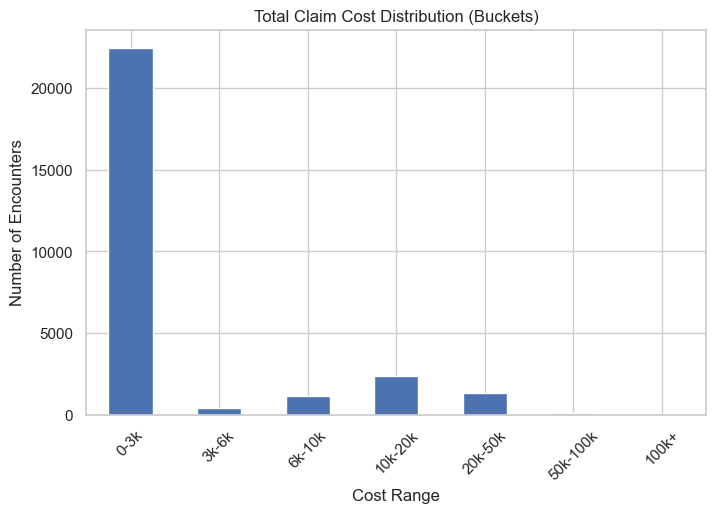

In [33]:
encounters["cost_bucket"].value_counts().sort_index().plot(
    kind="bar", figsize=(8,5)
)

plt.title("Total Claim Cost Distribution (Buckets)")
plt.xlabel("Cost Range")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45)
plt.show()

# KEY INSIGHTS
A majority of healthcare encounters fall within the lower cost brackets (0–10k), indicating that most treatments are routine and low-cost.

However, a small proportion of cases fall into higher cost ranges (above 50k), contributing disproportionately to overall healthcare expenditure.

This confirms a highly skewed cost structure, where a few high-cost cases drive the majority of financial burden.

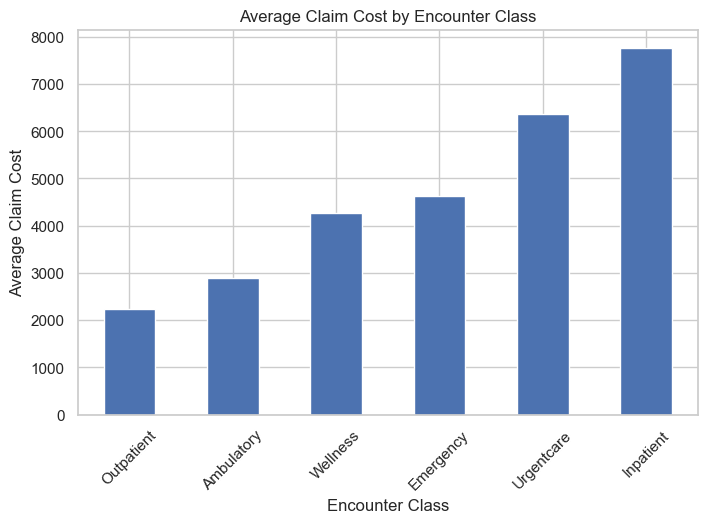

In [16]:
# Average cost by Encounter class
avg_cost_by_class = encounters.groupby("encounter_class")["total_claim_cost"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_cost_by_class.plot(kind="bar")
plt.title("Average Claim Cost by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Average Claim Cost")
plt.xticks(rotation=45)
plt.show()

# KEY INSIGHTS:

Inpatient encounters have the highest average claim cost, significantly higher than all other categories, indicating that hospital admissions are the primary drivers of healthcare expenditure.

Urgent care and emergency visits also show moderately high costs, reflecting the resource-intensive nature of acute treatments.

Outpatient and ambulatory visits have the lowest average costs, confirming that routine and preventive care is relatively inexpensive.

Wellness visits fall in the mid-range, suggesting moderate costs associated with preventive health assessments.

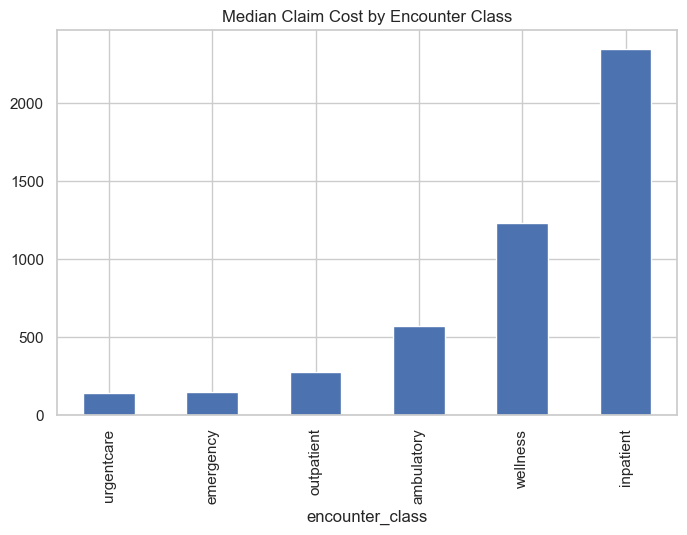

In [38]:
# Since cost distribution is highly skewed, median values are also analyzed alongside mean to avoid distortion from extreme high-cost cases.
median_cost = encounters.groupby("encounter_class")["total_claim_cost"].median().sort_values()

median_cost.plot(kind="bar", figsize=(8,5))
plt.title("Median Claim Cost by Encounter Class")
plt.show()

# KEY INSIGHTS:

Inpatient encounters have the highest median cost, confirming that hospitalization cases are consistently expensive.

Wellness and ambulatory visits fall in the mid-range, while emergency and urgent care show relatively lower median costs.

The difference between mean and median highlights the presence of extreme high-cost outliers in the dataset.

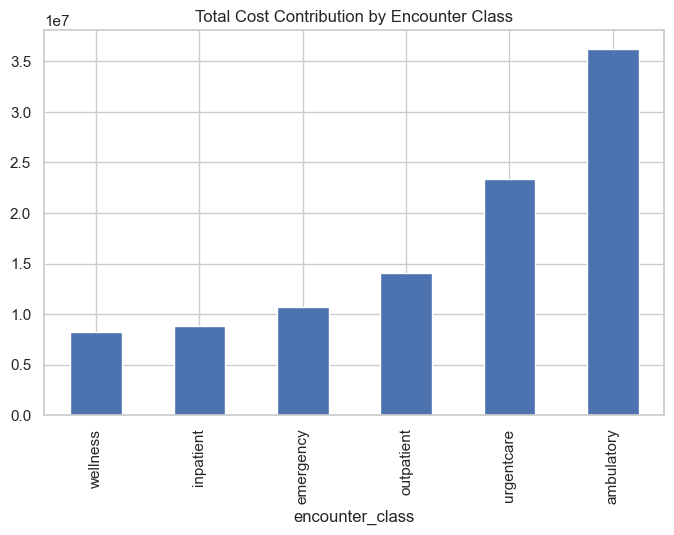

In [36]:
total_cost = encounters.groupby("encounter_class")["total_claim_cost"].sum().sort_values()

total_cost.plot(kind="bar", figsize=(8,5))
plt.title("Total Cost Contribution by Encounter Class")
plt.show()

# KEY INSIGHTS:

Ambulatory encounters contribute the highest total cost, followed by urgent care and outpatient visits.

Despite having lower per-visit cost, their high frequency drives overall expenditure.

Inpatient care, although expensive per case, contributes relatively less to total cost due to lower volume of admissions.

In [40]:
# Age vs Total Claim Cost
merged = encounters.merge(patients[["patient_id", "age", "gender"]], on="patient_id", how="left")

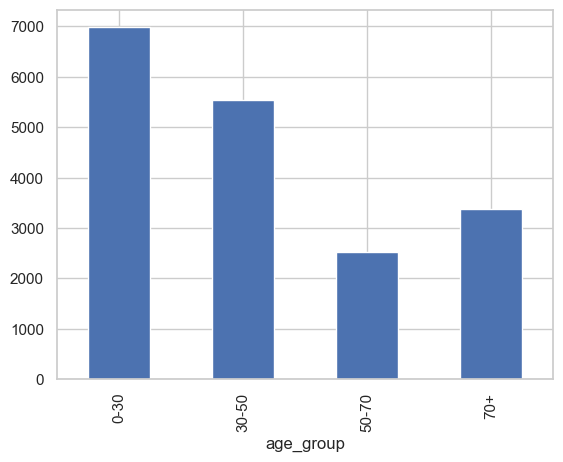

In [44]:
bins = [0, 30, 50, 70, 100]
labels = ["0-30", "30-50", "50-70", "70+"]

merged["age_group"] = pd.cut(merged["age"], bins=bins, labels=labels)

merged.groupby("age_group",observed=True)["total_claim_cost"].mean().plot(kind="bar")
plt.show()

# KEY INSIGHTS: 

The 0–30 age group shows the highest average claim cost, which is unexpected compared to typical healthcare trends.

The average cost declines in middle age (30–70) and rises again slightly in the 70+ group.

This suggests that younger patients may have fewer but more expensive treatments, while middle-aged groups experience more frequent but lower-cost healthcare utilization.

The elderly group (70+) shows increased costs again, likely due to age-related health complications and chronic conditions.

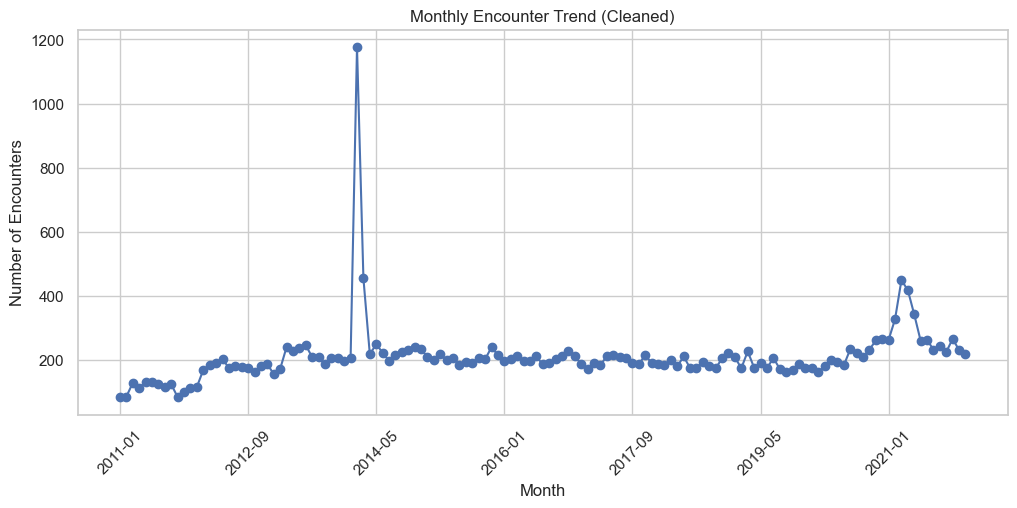

In [53]:
# Monthly Encounter Trend
encounters["start_date"] = pd.to_datetime(encounters["start_date"], errors="coerce")
encounters["year_month"] = encounters["start_date"].dt.to_period("M").astype(str)

monthly_trend = encounters["year_month"].value_counts().sort_index()

# remove last month if it is incomplete / suspicious
monthly_trend = monthly_trend[:-1]

plt.figure(figsize=(12,5))
monthly_trend.plot(kind="line", marker="o")
plt.title("Monthly Encounter Trend (Cleaned)")
plt.xlabel("Month")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45)
plt.show()

# KEY INSIGHTS:

The number of encounters remains relatively stable over time, generally ranging between 150–250 encounters per month, indicating consistent healthcare demand.

A sharp spike around 2014 stands out as a clear anomaly, with encounters rising far above normal levels, suggesting either a data issue or an unusual surge in healthcare activity.

Another noticeable increase around 2020–2021 may reflect heightened healthcare utilization, possibly due to external factors such as public health events.

The sudden drop to near zero at the end indicates incomplete or missing data for the latest period.